In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Load dataset
file_path = 'dataset/International Logistic Association Memberships.xlsx - Association ABC memberships.csv'
df = pd.read_csv(file_path, skipinitialspace=True)

print(f'Jumlah baris   : {df.shape[0]}')
print(f'Jumlah kolom   : {df.shape[1]}')
print(f'Nama kolom     : {df.columns.tolist()}')

Jumlah baris   : 71
Jumlah kolom   : 11
Nama kolom     : ['Member ID', 'Last name', 'First name', 'Address 1', 'Address 2', 'Address 3', 'Address 4', 'Address 5', 'Dues amount', 'Membership valid through', 'Member type']


In [2]:
df.head(7)

,Member ID,Last name,First name,Address 1,Address 2,Address 3,Address 4,Address 5,Dues amount,Membership valid through,Member type
0,100011,Tsao,Danny,27 Wu Tzu St,Tamshui 251,NaN,Taiwan,NaN,$200,3/25/2021,Professional Member
1,100012,Lei,Colleen,88 6th Avenue Teda,300457 TIANJIN,NaN,China,NaN,$500,10/12/2023,Corporate Member
2,100013,Roth,Nancy,Hoefenstrasse 31,Muehlethal,NaN,Switzerland,4812,$100,1/11/2023,Student Associate
3,100014,Meneses Contreras,Karl-Oscar,Poniente 134 Ste. 740,02300 México,DIF,Mexico,NaN,$500,2/26/2021,Corporate Member
4,100015,Nunez,Helmut,Andador Pinos 345,45235 Zapopan,JAL,Mexico,NaN,$200,7/29/2023,Professional Member
5,100016,Fitzpatrick,Dmitry,22 Hemingford Pl,Whitby,ON,Canada,L1R 1G1,$100,12/15/2007,Student Associate
6,100017,Andreu,Leya,Nevada de Colima 104,20280 Aguascalientes,NaN,Mexico,NaN,$200,3/31/2021,Professional Member


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Member ID                 71 non-null     int64
 1   Last name                 71 non-null     str  
 2   First name                71 non-null     str  
 3   Address 1                 71 non-null     str  
 4   Address 2                 71 non-null     str  
 5   Address 3                 30 non-null     str  
 6   Address 4                 71 non-null     str  
 7   Address 5                 39 non-null     str  
 8   Dues amount               71 non-null     str  
 9   Membership valid through  71 non-null     str  
 10  Member type               71 non-null     str  
dtypes: int64(1), str(10)
memory usage: 6.2 KB


In [4]:
df.describe(include='all')

,Member ID,Last name,First name,Address 1,Address 2,Address 3,Address 4,Address 5,Dues amount,Membership valid through,Member type
count,71.000000,71,71,71,71,30,71,39,71,71,71
unique,NaN,67,69,68,64,9,22,37,4,63,5
top,NaN,de Alava Casado,Christophe,Emilio Arrieta 23,Mississauga,ON,Canada,31002,$200,3/31/2021,Professional Member
freq,NaN,2,2,2,3,15,23,2,40,2,39
mean,100045.929577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,21.106752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,100011.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,100027.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,100045.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,100064.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.isnull().sum()

Member ID                    0
Last name                    0
First name                   0
Address 1                    0
Address 2                    0
Address 3                   41
Address 4                    0
Address 5                   32
Dues amount                  0
Membership valid through     0
Member type                  0
dtype: int64

In [6]:
df['Dues amount (numeric)'] = (
    df['Dues amount']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

total_contribution = df['Dues amount (numeric)'].sum()

average_contribution = df['Dues amount (numeric)'].mean()

print('============================================')
print(f'  Total Kontribusi Seluruh Anggota  : ${total_contribution:,.2f}')
print(f'  Rata-rata Kontribusi per Anggota  : ${average_contribution:,.2f}')
print('============================================')

summary = df.groupby('Member type')['Dues amount (numeric)'].agg(
    Jumlah_Anggota='count',
    Total_Kontribusi='sum',
    Rata_Rata_Kontribusi='mean'
).reset_index()
summary.columns = ['Tipe Anggota', 'Jumlah Anggota', 'Total Kontribusi ($)', 'Rata-rata Kontribusi ($)']
summary

  Total Kontribusi Seluruh Anggota  : $18,400.00
  Rata-rata Kontribusi per Anggota  : $259.15


,Tipe Anggota,Jumlah Anggota,Total Kontribusi ($),Rata-rata Kontribusi ($)
0,Corporate Member,7,3500.0,500.0
1,Corporate Voting,5,5000.0,1000.0
2,Professional Member,39,7800.0,200.0
3,Student Associate,19,1900.0,100.0
4,{rofessional Member,1,200.0,200.0


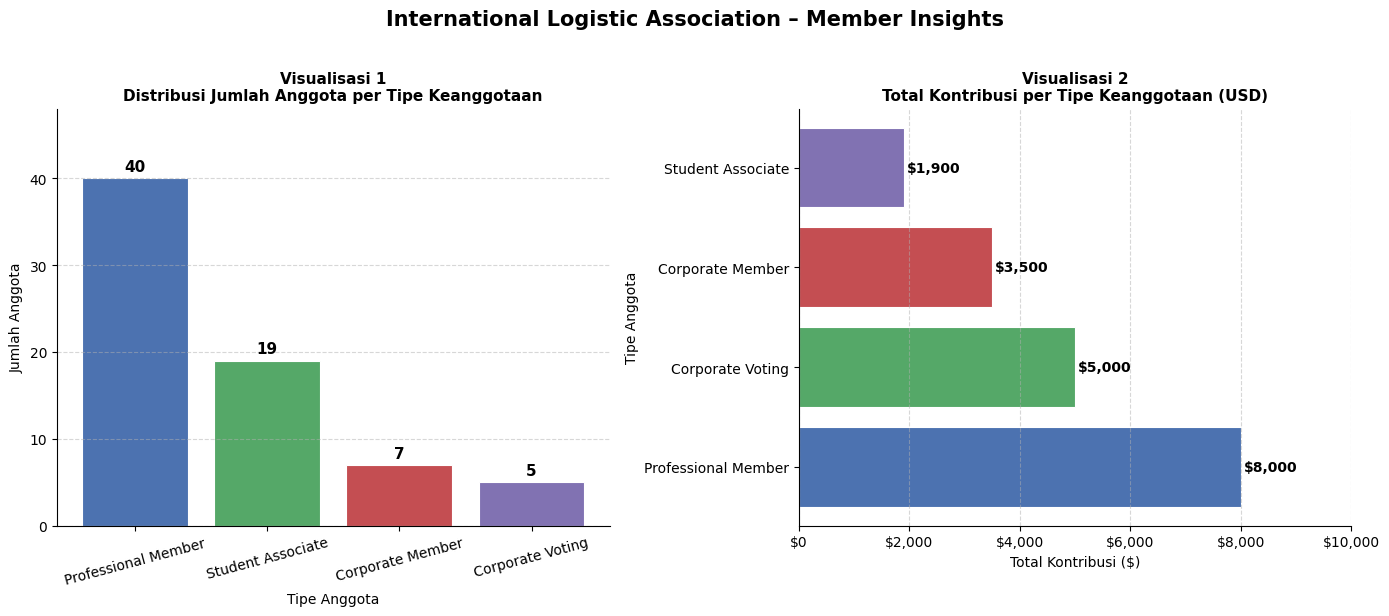

In [ ]:
df['Member type'] = df['Member type'].str.strip().replace('{rofessional Member', 'Professional Member')

member_counts = df['Member type'].value_counts()

contribution_by_type = df.groupby('Member type')['Dues amount (numeric)'].sum().sort_values(ascending=False)

colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('International Logistic Association – Member Insights', fontsize=15, fontweight='bold', y=1.02)

bars1 = axes[0].bar(member_counts.index, member_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Visualisasi 1\nDistribusi Jumlah Anggota per Tipe Keanggotaan', fontsize=11, fontweight='bold')
axes[0].set_xlabel('Tipe Anggota', fontsize=10)
axes[0].set_ylabel('Jumlah Anggota', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)
axes[0].set_ylim(0, member_counts.max() * 1.2)
for bar, val in zip(bars1, member_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.5)
axes[0].spines[['top', 'right']].set_visible(False)

# ── Visualisasi 2: Horizontal Bar – Total Kontribusi per Tipe ──────────────
bars2 = axes[1].barh(contribution_by_type.index, contribution_by_type.values,
                     color=colors[:len(contribution_by_type)], edgecolor='white', linewidth=0.8)
axes[1].set_title('Visualisasi 2\nTotal Kontribusi per Tipe Keanggotaan (USD)', fontsize=11, fontweight='bold')
axes[1].set_xlabel('Total Kontribusi ($)', fontsize=10)
axes[1].set_ylabel('Tipe Anggota', fontsize=10)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_xlim(0, contribution_by_type.max() * 1.25)
for bar, val in zip(bars2, contribution_by_type.values):
    axes[1].text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
                 f'${val:,.0f}', va='center', fontsize=10, fontweight='bold')
axes[1].grid(axis='x', linestyle='--', alpha=0.5)
axes[1].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('member_insights.png', dpi=150, bbox_inches='tight')
plt.show()